<a href="https://colab.research.google.com/github/Claud1601/CN7030-Assignment/blob/main/LAB_15_Silakshana_Dinesh_Rathnayaka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator


spark = SparkSession.builder \
    .appName("Property_Price_LinearRegression") \
    .master("local[*]") \
    .getOrCreate()

df = spark.read.csv(
    "/content/drive/MyDrive/Colab Notebooks/property.csv",
    header=True,
    inferSchema=True
)


df.show(5)

+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
+--------------+------------+-------------+----------+--------+------------------+
only showing top 5 rows


In [2]:
print("Total Records:", df.count())

df.printSchema()

df.describe().show()

Total Records: 1000000
root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)

+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|   Square_Footage|     Num_Bedrooms|     Num_Bathrooms|       Year_Built|         Lot_Size|             Price|
+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|          1000000|          1000000|           1000000|          1000000|          1000000|           1000000|
|   mean|      2750.657104|         3.501114|          2.500439|       1960.52736|      5502.373911| 581839.6653163614|
| stddev|1298.569362387213|1.708173784151257|1.1178528780094728|35.21780350510348|2598.885882999355|260685.36722

In [3]:
from pyspark.sql.functions import col, isnan, when, count

df.select(
    [
        count(
            when(isnan(c) | col(c).isNull(), c)
        ).alias(c)
        for c in df.columns
    ]
).show()

+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



In [4]:
# Define feature combinations for different Linear Regression models

model1_features = [
    "Square_Footage",
    "Num_Bedrooms",
    "Num_Bathrooms",
    "Year_Built",
    "Lot_Size"
]


model2_features = [
    "Square_Footage",
    "Num_Bedrooms",
    "Num_Bathrooms"
]


model3_features = [
    "Square_Footage",
    "Num_Bedrooms",
    "Lot_Size"
]


model4_features = [
    "Square_Footage",
    "Num_Bathrooms",
    "Year_Built",
    "Lot_Size"
]


print("Feature selection completed")

Feature selection completed


In [5]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator



def train_linear_regression(features):

    # Convert columns into feature vector
    assembler = VectorAssembler(
        inputCols=features,
        outputCol="Features"
    )


    # Scale features
    scaler = StandardScaler(
        inputCol="Features",
        outputCol="scaled_Features"
    )


    # Linear Regression model
    lr = LinearRegression(
        labelCol="Price",
        featuresCol="scaled_Features"
    )


    # Create pipeline
    pipeline = Pipeline(
        stages=[
            assembler,
            scaler,
            lr
        ]
    )


    # Split dataset
    train_data, test_data = df.randomSplit(
        [0.8, 0.2],
        seed=42
    )


    # Train model
    model = pipeline.fit(train_data)


    # Prediction
    predictions = model.transform(test_data)


    # Evaluate R2
    evaluator = RegressionEvaluator(
        labelCol="Price",
        predictionCol="prediction",
        metricName="r2"
    )


    r2_score = evaluator.evaluate(predictions)


    return r2_score



print("Linear Regression function created successfully")

Linear Regression function created successfully


Four different Linear Regression models were built by utilizing different sets of property features. Each model was then tested through the R² metric to find out how much variance in the property price could be explained by those particular features.

In [6]:
# Train different Linear Regression models

r2_results = {}


# Model 1

r2_results["Model 1 (5 Features)"] = train_linear_regression(
    model1_features
)


# Model 2

r2_results["Model 2 (3 Features)"] = train_linear_regression(
    model2_features
)


# Model 3

r2_results["Model 3 (3 Features)"] = train_linear_regression(
    model3_features
)


# Model 4

r2_results["Model 4 (4 Features)"] = train_linear_regression(
    model4_features
)



# Display Results

for model, score in r2_results.items():
    print(model, "R² Score:", score)

Model 1 (5 Features) R² Score: 0.9940979930679152
Model 2 (3 Features) R² Score: 0.9939063958651388
Model 3 (3 Features) R² Score: 0.9937412631735472
Model 4 (4 Features) R² Score: 0.9930428106300507


Of the four Linear Regression models trained, the best one was Model 1, which had the highest value of R², which is 0.99410. The variables that were used for this model include all the variables at disposal, namely Square_Footage, Num_Bedrooms, Num_Bathrooms, Year_Built, and Lot_Size.

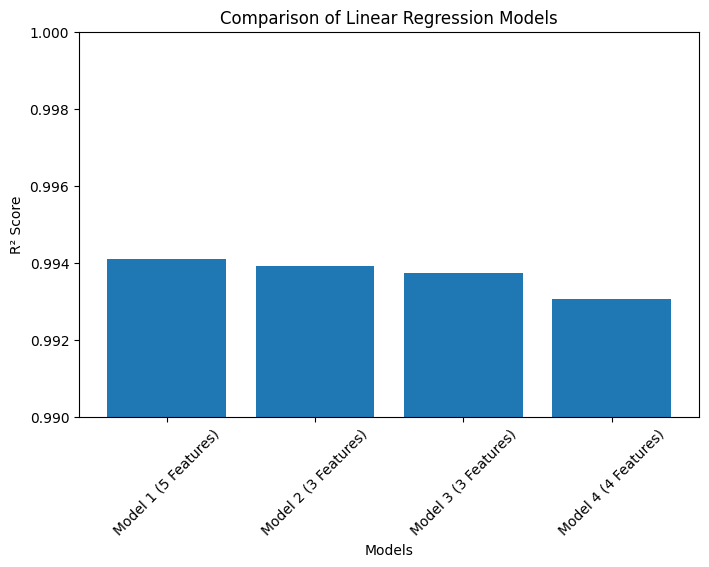

In [7]:
import matplotlib.pyplot as plt


models = list(r2_results.keys())
scores = list(r2_results.values())


plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Comparison of Linear Regression Models")

plt.xticks(rotation=45)

plt.ylim(0.99,1)

plt.show()

Conclusion

This exercise is an example of transferring the original machine learning algorithm from one dataset to another. In particular, Linear Regression algorithm was used and adapted for a property dataset with the original one being applied to the Diabetes dataset. The task was to predict property prices with the help of multiple linear regression and to compare models' performance based on their R-squared values.

They were chosen since those are the factors that may affect the price of a property. The target variable (dependent one) – Price – was selected since it is the value that should be predicted by the algorithm. Multiple models have been created based on the combinations of these input features.

After models were trained, their R-squared values have been compared. The results showed that Model 1 which included all five independent variables produced the best R-squared value of 0.99410. It means that about 99.41% of variation in property prices can be explained by the model. Other models performed very well too, however their R-squared values were only slightly worse than the one of Model 1. Thus, including relevant property-related features in the model increased its performance slightly.

One of the challenges was adapting the original code of Spark to the new dataset (from Diabetes to property). It was necessary to replace the old columns' names with the new property-related ones and to change the target variable from progression to Price. Another challenge that could be faced in this exercise was handling a large property dataset (one million of records). However, Spark successfully processed the high amount of data which proved the efficiency of distributed processing.

Overall, this activity was useful for gaining practical experience in working with multiple linear regression algorithm. It helped me to learn how important it is to choose proper input features, to compare models' performance based on appropriate evaluation metrics and how to use machine learning pipelines in Spark.

In [8]:
!pip3 install nbconvert -q

In [10]:
from google.colab import drive
drive.mount('/content/drive')

notebook_filename = "LAB_15_Silakshana_Dinesh_Rathnayaka.ipynb"
notebook_path = f"/content/drive/MyDrive/Colab Notebooks/LAB_15_Silakshana_Dinesh_Rathnayaka.ipynb"


!jupyter nbconvert --to html "{notebook_path}" --output-dir "/content/"

print(f"Notebook '{notebook_filename}' successfully converted to HTML and saved in /content/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/LAB_15_Silakshana_Dinesh_Rathnayaka.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 344950 bytes to /content/LAB_15_Silakshana_Dinesh_Rathnayaka.html
Notebook 'LAB_15_Silakshana_Dinesh_Rathnayaka.ipynb' successfully converted to HTML and saved in /content/
